# Annotate 4 góc tài liệu

Notebook này dùng để gắn nhãn 4 góc tài liệu cho test set của Document Scanner.

## Hướng dẫn chạy
1. Chạy cell **Đọc dữ liệu từ kaggle** để tải dữ liệu từ kaggle.
2. Chạy cell **Annotate** — với mỗi ảnh: click lần lượt 4 góc theo thứ tự **TL → TR → BR → BL**.
   - Phím `s` (hoặc nút *Save*): lưu khi đã đủ 4 điểm và sang ảnh kế.
   - Phím `r` (hoặc nút *Reset*): xoá hết điểm để click lại.
   - Phím `n` (hoặc nút *Skip*): bỏ qua ảnh hiện tại.
   - Phím `q` (hoặc nút *Quit*): dừng toàn bộ vòng lặp.
3. Mỗi ảnh sẽ tạo 1 file `<tên>.json` trong `OUTPUT_DIR`.

## Format JSON
```json
{
  "filename": "IMG_001.jpg",
  "image_size": [width, height],
  "has_document": true,
  "corners": [[x_tl, y_tl], [x_tr, y_tr], [x_br, y_br], [x_bl, y_bl]]
}
```
Toạ độ được trả về theo **ảnh gốc** (đã quy đổi từ kích thước hiển thị).

## 1. Đọc data từ kaggle

In [ ]:
import os
from google.colab import files


!rm -rf ~/.cache/kaggle
!rm -rf /content/dataset

!kaggle datasets download -d tiendq/scanner --force
!unzip -q scanner.zip -d /content

In [ ]:
from pathlib import Path

IMAGE_DIR = Path('/content/dataset/test')
OUTPUT_DIR = Path('/content/label')

IMAGE_EXTS = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG')
MAX_DISPLAY = 1200

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'IMAGE_DIR  = {IMAGE_DIR} (exists={IMAGE_DIR.exists()})')
print(f'OUTPUT_DIR = {OUTPUT_DIR}')

## 2. Đọc data từ drive

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# from pathlib import Path

# # Thư mục chứa ảnh cần annotate (ảnh test set)
# IMAGE_DIR = Path('/content/drive/MyDrive/CV/pr/dataset/test')

# # Thư mục lưu file annotation (.json). Sẽ tự tạo nếu chưa có.
# OUTPUT_DIR = Path('/content/drive/MyDrive/CV/pr/dataset/test/label')

# # Các đuôi ảnh sẽ quét
# IMAGE_EXTS = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG')

# # Kích thước hiển thị tối đa (cạnh dài). Click vẫn được quy đổi về tọa độ ảnh gốc.
# MAX_DISPLAY = 1200

# OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# print(f'IMAGE_DIR  = {IMAGE_DIR}  (exists={IMAGE_DIR.exists()})')
# print(f'OUTPUT_DIR = {OUTPUT_DIR}')

IMAGE_DIR  = /content/drive/MyDrive/CV/pr/dataset/test/test_detection  (exists=True)
OUTPUT_DIR = /content/drive/MyDrive/CV/pr/dataset/test/test_detection/label


## 3. Hàm pick 4 góc bằng JavaScript canvas

OpenCV `imshow` không chạy được trên Colab nên dùng canvas + JS callback. Hàm trả về:
- `('save', [(x,y)*4])` khi user lưu xong
- `('skip', None)` khi bỏ qua
- `('quit', None)` khi muốn dừng

In [ ]:
from base64 import b64encode

import cv2
from google.colab.output import eval_js


def pick_corners(img_bgr, max_display=MAX_DISPLAY):
    h, w = img_bgr.shape[:2]
    scale = min(1.0, max_display / max(h, w))
    if scale < 1.0:
        disp = cv2.resize(img_bgr, None, fx=scale, fy=scale)
    else:
        disp = img_bgr.copy()
    dh, dw = disp.shape[:2]

    ok, buf = cv2.imencode('.jpg', disp, [cv2.IMWRITE_JPEG_QUALITY, 90])
    if not ok:
        raise RuntimeError('Không encode được ảnh để hiển thị.')
    b64 = b64encode(buf.tobytes()).decode('utf-8')

    js = '''
    (async function pickPoints() {
      const wrap = document.createElement('div');
      wrap.style.cssText = 'font-family: sans-serif; padding: 6px;';
      const info = document.createElement('div');
      info.innerText = 'Click 4 góc theo thứ tự: TL \u2192 TR \u2192 BR \u2192 BL. Phím s = save, r = reset, n = skip, q = quit.';
      info.style.cssText = 'margin: 4px 0; color:#333;';
      wrap.appendChild(info);

      const canvas = document.createElement('canvas');
      canvas.width = __W__;
      canvas.height = __H__;
      canvas.style.cssText = 'border:1px solid #888; cursor:crosshair; max-width:100%;';
      canvas.tabIndex = 0;
      wrap.appendChild(canvas);

      const status = document.createElement('div');
      status.style.cssText = 'margin: 4px 0; color:#0066cc;';
      wrap.appendChild(status);

      const row = document.createElement('div');
      const mkBtn = (txt) => { const b = document.createElement('button'); b.innerText = txt; b.style.cssText = 'margin:4px; padding:4px 10px;'; row.appendChild(b); return b; };
      const saveBtn = mkBtn('Save (s)');
      const resetBtn = mkBtn('Reset (r)');
      const skipBtn = mkBtn('Skip (n)');
      const quitBtn = mkBtn('Quit (q)');
      wrap.appendChild(row);

      document.body.appendChild(wrap);
      canvas.focus();

      const ctx = canvas.getContext('2d');
      const img = new Image();
      img.src = 'data:image/jpeg;base64,__B64__';
      await new Promise((res, rej) => { img.onload = res; img.onerror = rej; });

      const labels = ['TL', 'TR', 'BR', 'BL'];
      let points = [];

      function redraw() {
        ctx.drawImage(img, 0, 0, canvas.width, canvas.height);
        if (points.length >= 2) {
          ctx.strokeStyle = '#00ff00';
          ctx.lineWidth = 2;
          ctx.beginPath();
          ctx.moveTo(points[0][0], points[0][1]);
          for (let i = 1; i < points.length; i++) ctx.lineTo(points[i][0], points[i][1]);
          if (points.length === 4) ctx.closePath();
          ctx.stroke();
        }
        for (let i = 0; i < points.length; i++) {
          const [x, y] = points[i];
          ctx.fillStyle = '#00ff00';
          ctx.beginPath(); ctx.arc(x, y, 6, 0, 2 * Math.PI); ctx.fill();
          ctx.fillStyle = '#fff'; ctx.strokeStyle = '#000'; ctx.lineWidth = 3;
          ctx.font = 'bold 16px sans-serif';
          ctx.strokeText(labels[i], x + 8, y - 8);
          ctx.fillText(labels[i], x + 8, y - 8);
        }
        status.innerText = 'Đã chọn ' + points.length + '/4';
      }
      redraw();

      canvas.addEventListener('click', (ev) => {
        const rect = canvas.getBoundingClientRect();
        const x = (ev.clientX - rect.left) * canvas.width / rect.width;
        const y = (ev.clientY - rect.top) * canvas.height / rect.height;
        if (points.length < 4) { points.push([x, y]); redraw(); }
      });

      return await new Promise((resolve) => {
        function done(action) {
          document.removeEventListener('keydown', onKey);
          wrap.remove();
          resolve({action: action, points: points});
        }
        function onKey(ev) {
          if (ev.key === 's') { if (points.length === 4) done('save'); else status.innerText = 'Cần đủ 4 điểm trước khi save!'; }
          else if (ev.key === 'r') { points = []; redraw(); }
          else if (ev.key === 'n') { done('skip'); }
          else if (ev.key === 'q') { done('quit'); }
        }
        saveBtn.onclick = () => { if (points.length === 4) done('save'); else status.innerText = 'Cần đủ 4 điểm trước khi save!'; };
        resetBtn.onclick = () => { points = []; redraw(); };
        skipBtn.onclick = () => done('skip');
        quitBtn.onclick = () => done('quit');
        document.addEventListener('keydown', onKey);
      });
    })()
    '''
    js = js.replace('__W__', str(dw)).replace('__H__', str(dh)).replace('__B64__', b64)

    result = eval_js(js)
    if not result:
        return 'quit', None
    action = result.get('action', 'quit')
    if action != 'save':
        return action, None
    pts = result.get('points') or []
    if len(pts) != 4:
        return 'skip', None
    # Quy đổi từ tọa độ hiển thị về tọa độ ảnh gốc
    corners = [(float(x) / scale, float(y) / scale) for x, y in pts]
    return 'save', corners


## 4. Annotate toàn bộ ảnh trong `IMAGE_DIR`

Vòng lặp sẽ:
- Bỏ qua ảnh đã có file `<tên>.json` trong `OUTPUT_DIR`.
- Hiện canvas cho từng ảnh, ghi JSON ngay sau khi save (không mất dữ liệu nếu Colab disconnect).
- Dừng khi user bấm Quit.

In [ ]:
import json
import cv2
import time
from IPython.display import clear_output
from pathlib import Path

def list_images(image_dir, exts=IMAGE_EXTS):
    files = []
    for ext in exts:
        files.extend(image_dir.glob(f'*{ext}'))
    seen = set(); unique = []
    for f in sorted(files):
        if f.name not in seen:
            seen.add(f.name); unique.append(f)
    return unique

def annotate_corners(image_dir, output_dir, max_display=MAX_DISPLAY):
    image_dir = Path(image_dir); output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    images = list_images(image_dir)
    todo = [p for p in images if not (output_dir / f'{p.stem}.json').exists()]

    print(f'Bắt đầu xử lý {len(todo)} ảnh còn lại...')

    saved = skipped = 0
    for idx, img_path in enumerate(todo, 1):
        img = cv2.imread(str(img_path))
        if img is None: continue

        print(f'\n>>> [{idx}/{len(todo)}] Đang mở: {img_path.name}')

        action, corners = pick_corners(img, max_display=max_display)

        if action == 'quit':
            print('\n[!] Đã chủ động dừng.')
            break
        elif action == 'skip' or corners is None:
            print(f' - Bỏ qua {img_path.name}')
            skipped += 1
        else:
            h, w = img.shape[:2]
            ann = {
                'filename': img_path.name,
                'image_size': [int(w), int(h)],
                'has_document': True,
                'corners': [[float(x), float(y)] for x, y in corners],
            }
            out_path = output_dir / f'{img_path.stem}.json'
            with open(out_path, 'w', encoding='utf-8') as f:
                json.dump(ann, f, indent=2, ensure_ascii=False)
            saved += 1
            print(f' - Đã lưu: {out_path.name}')

    print(f'\nDONE! Tổng cộng đã lưu thêm {saved} file.')

annotate_corners(IMAGE_DIR, OUTPUT_DIR)

## 5. Kiểm tra annotation đã lưu

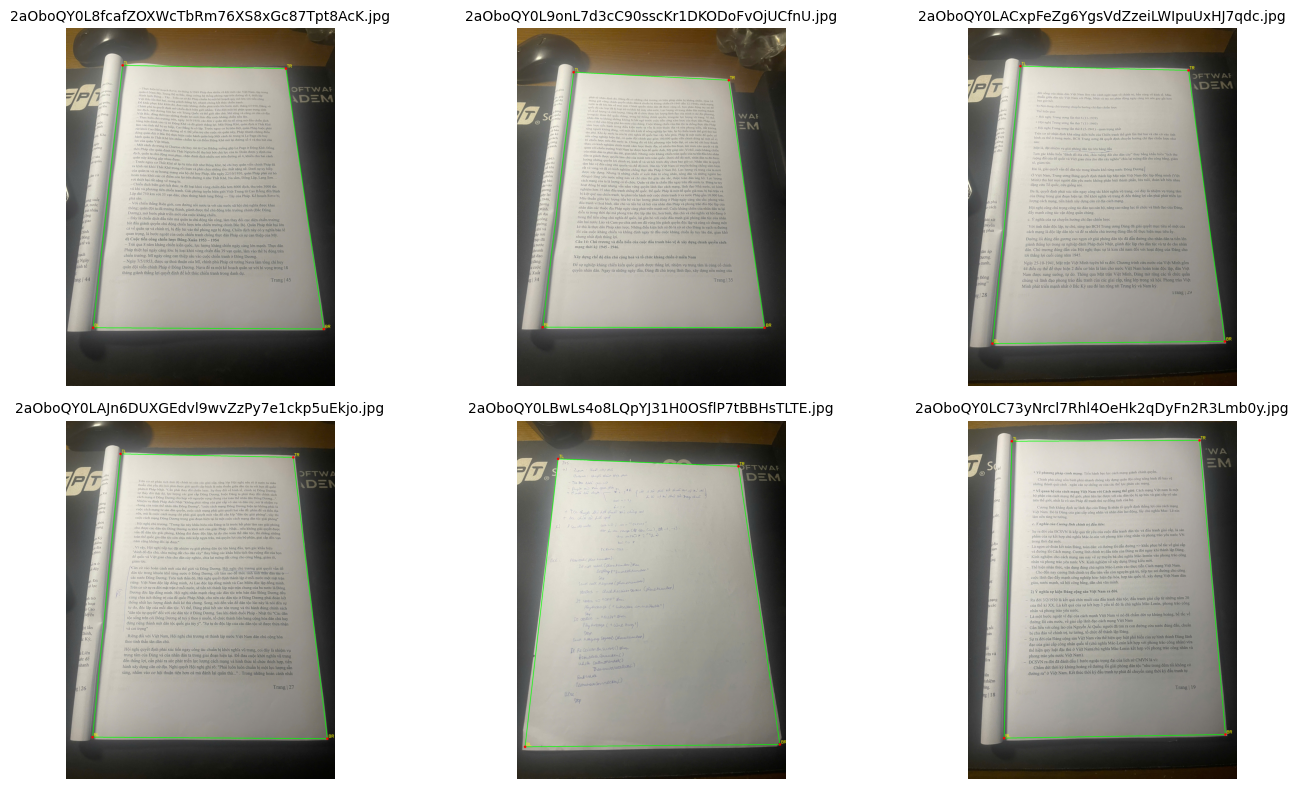

In [ ]:
import json

import cv2
import numpy as np
from matplotlib import pyplot as plt


def preview_annotations(image_dir, output_dir, n=6):
    image_dir = Path(image_dir); output_dir = Path(output_dir)
    json_files = sorted(output_dir.glob('*.json'))[:n]
    if not json_files:
        print('Chưa có annotation nào.')
        return
    cols = 3; rows = (len(json_files) + cols - 1) // cols
    plt.figure(figsize=(5 * cols, 4 * rows))
    for i, jp in enumerate(json_files, 1):
        with open(jp, encoding='utf-8') as f:
            ann = json.load(f)
        img_path = image_dir / ann['filename']
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        pts = np.array(ann['corners'], dtype=np.int32)
        cv2.polylines(rgb, [pts], True, (0, 255, 0), max(2, img.shape[1] // 400))
        for (x, y), lab in zip(pts, ['TL', 'TR', 'BR', 'BL']):
            cv2.circle(rgb, (int(x), int(y)), max(4, img.shape[1] // 200), (255, 0, 0), -1)
            cv2.putText(rgb, lab, (int(x) + 8, int(y) - 8), cv2.FONT_HERSHEY_SIMPLEX,
                        max(0.6, img.shape[1] / 2000), (255, 255, 0), 2)
        ax = plt.subplot(rows, cols, i)
        ax.imshow(rgb); ax.set_title(ann['filename'], fontsize=10); ax.axis('off')
    plt.tight_layout(); plt.show()


preview_annotations(IMAGE_DIR, OUTPUT_DIR, n=6)